# 02 — XGBoost Surrogate (from scratch)
**Model:** Gradient Boosted Regression Trees — implemented from first principles.

**Why from scratch:**
Building XGBoost manually forces you to understand every piece:
residual fitting, tree structure, learning rate, regularisation.
No `xgboost` or `sklearn` ensemble module is used here.

**XGBoost core idea (simplified):**
```
F₀(x) = mean(y)              # initial prediction
for m = 1..M:
    r = y − Fₘ₋₁(x)         # residuals (pseudo-gradients)
    hₘ = fit a small tree to r
    Fₘ(x) = Fₘ₋₁(x) + η·hₘ(x)   # η = learning rate
```
Each tree corrects what the previous ensemble got wrong.

**Limitation with 17 points:**
Tree methods are not naturally suited to very small 1D datasets.
No uncertainty bands (unlike GP). Use LOO-CV error as the reliability estimate.

**Outputs saved to** `../analysis/`:
- `xgb_predictions.png`
- `xgb_loo_residuals.png`
- `xgb_results.pkl`


---
## Cell 1 — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, sys, os
import warnings; warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

sys.path.insert(0, os.path.dirname(os.path.abspath('data_utils.py')))

from data_utils import (load_data, plot_loo_residuals,
                        LeaveOneOut, mean_absolute_error, r2_score,
                        TARGETS, PALETTE)

print('Imports OK — no xgboost module, no sklearn')

Imports OK — no xgboost module, no sklearn


/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


---
## Cell 2 — Load Data

In [2]:
DATA_PATHS = {
    'raw':       '../analysis/elastic_constants_fecr_raw.csv',
    'corrected': '../analysis/elastic_constants_fecr_corrected.csv',
}

results = {}

for mode, path in DATA_PATHS.items():
    d = load_data(path)
    df           = d['df']
    tier = np.where(df['n_cr'] <= 9,  'A',
           np.where(df['n_cr'] <= 13, 'B', 'C'))
    results[mode] = dict(
        df             = df,
        X              = d['X'],
        X_pred         = d['X_pred'],
        x_pred_atoms   = d['x_pred_atoms'],
        targets        = d['targets'],
        alpha          = d['alpha'],
        noise_gpa      = d['noise_gpa'],
        flagged        = d['flagged'],
        afm_init       = d['afm_init'],
        vcr_geometry   = d['vcr_geometry'],
        cubic_enforced = d['cubic_enforced'],
        tier           = tier,
        xgb_models     = {},
        xgb_results    = {},
    )

print('\nBoth datasets loaded.')
for mode in DATA_PATHS:
    r = results[mode]
    print(f"  {mode:10s}: {len(r['df'])} tags | "
          f"noise range C11: {r['alpha']['C11'].min():.2f}–"
          f"{r['alpha']['C11'].max():.2f} GPa²")


Loaded 17 tags — mode: RAW
tag            n_cr  σ C11+2C12  σ C11-C12   σ C44   afm  vcr_geo  cub_enf
--------------------------------------------------------------------
fe16cr00          0       1.000      1.000   1.000 False    False    False
fe15cr01          1       1.000      1.000   1.000 False    False    False
fe14cr02          2       1.000      1.000   1.000 False    False    False
fe13cr03          3       1.000      1.000   1.000 False    False    False
fe12cr04          4       1.000      1.000   1.000 False    False    False
fe11cr05          5       1.000      1.000   1.000 False    False    False
fe10cr06          6       1.000      1.000   1.000 False    False    False
fe09cr07          7       1.000      1.000   1.000 False    False    False
fe08cr08          8       1.000      1.000   1.000 False    False    False
fe07cr09          9       1.000      1.000   1.000 False    False    False
fe06cr10         10       1.000      1.000   1.000 False    False    False
fe0

---
## Cell 3 — XGBoost Implementation from Scratch

### Key components built here:

**DecisionStump** — a depth-1 regression tree (the 'weak learner').
Finds the best single split threshold that minimises MSE on the residuals.

**WeightedDecisionStump** — same but weighted by sample importance.
Used to down-weight the 3 flagged DFT points.

**GradientBoostedTrees** — the ensemble:
- starts from the weighted mean
- each round fits a stump to the current residuals
- applies L2 regularisation on leaf values (λ parameter)
- learning rate η shrinks each tree's contribution

**Hyperparameters (tunable):**
- `n_estimators` — number of boosting rounds
- `eta` — learning rate (smaller = slower but more stable)
- `max_depth` — kept at 1 (stump) because we have only 17 points
- `lam` — L2 regularisation on leaf weights
- `subsample` — fraction of data used per round (set 1.0 here given tiny N)


In [3]:
# ─────────────────────────────────────────────────────────────────────────
# DECISION STUMP (depth-1 regression tree)
# ─────────────────────────────────────────────────────────────────────────
class DecisionStump:
    """
    Depth-1 regression tree. Finds best split of 1D input X to minimise
    weighted MSE of residuals r.

    Attributes after fit:
        threshold  : split value
        left_val   : predicted value for X <= threshold
        right_val  : predicted value for X >  threshold
    """
    def __init__(self, lam=1.0):
        self.lam = lam          # L2 regularisation on leaf values
        self.threshold  = None
        self.left_val   = None
        self.right_val  = None

    def _leaf_value(self, g, w):
        """
        Optimal leaf value in XGBoost:
          v* = -sum(g) / (sum(w) + λ)
        where g = residuals, w = sample weights.
        """
        return -np.sum(g) / (np.sum(w) + self.lam) if len(g) > 0 else 0.0

    def _gain(self, g_L, w_L, g_R, w_R):
        """
        XGBoost split gain:
          Gain = ½ [ G_L²/(H_L+λ) + G_R²/(H_R+λ) − (G_L+G_R)²/(H_L+H_R+λ) ]
        where G = sum(g), H = sum(w).
        Gain > 0 means the split reduces the weighted loss.
        """
        def score(g, w): return (np.sum(g)**2) / (np.sum(w) + self.lam) if len(g)>0 else 0.
        return 0.5 * (score(g_L,w_L) + score(g_R,w_R)
                      - score(np.concatenate([g_L,g_R]), np.concatenate([w_L,w_R])))

    def fit(self, X, g, w=None):
        """
        X : (n,1) feature array
        g : (n,)  residuals (negative gradient of L2 loss = y - F(x))
        w : (n,)  sample weights (None = uniform)
        """
        n = len(X)
        if w is None: w = np.ones(n)
        x = X.flatten()
        best_gain, best_thr = -np.inf, None
        # Try every midpoint between adjacent unique values as split
        thresholds = (np.sort(np.unique(x))[:-1] + np.sort(np.unique(x))[1:]) / 2
        for thr in thresholds:
            L = x <= thr;  R = ~L
            if L.sum() == 0 or R.sum() == 0: continue
            gain = self._gain(g[L], w[L], g[R], w[R])
            if gain > best_gain:
                best_gain, best_thr = gain, thr
        if best_thr is None:          # no valid split found
            best_thr = x.mean()
        self.threshold = best_thr
        L = x <= best_thr;  R = ~L
        self.left_val  = self._leaf_value(g[L], w[L])
        self.right_val = self._leaf_value(g[R], w[R])
        return self

    def predict(self, X):
        x = X.flatten()
        return np.where(x <= self.threshold, self.left_val, self.right_val)

print('DecisionStump class defined')

DecisionStump class defined


In [4]:
# ─────────────────────────────────────────────────────────────────────────
# GRADIENT BOOSTED TREES ENSEMBLE
# ─────────────────────────────────────────────────────────────────────────
class GradientBoostedTrees:
    """
    XGBoost-style gradient boosting with depth-1 trees (stumps).

    Parameters
    ----------
    n_estimators : int   — number of boosting rounds
    eta          : float — learning rate  (0 < η ≤ 1)
    lam          : float — L2 leaf regularisation
    subsample    : float — fraction of data per round (1.0 = use all)
    """
    def __init__(self, n_estimators=100, eta=0.1, lam=1.0, subsample=1.0, seed=42):
        self.n_estimators = n_estimators
        self.eta          = eta
        self.lam          = lam
        self.subsample    = subsample
        self.seed         = seed
        self.trees        = []
        self.F0           = None     # initial prediction
        self.train_loss   = []

    def fit(self, X, y, sample_weight=None):
        rng = np.random.default_rng(self.seed)
        n   = len(y)
        if sample_weight is None:
            sample_weight = np.ones(n)
        sample_weight = sample_weight / sample_weight.sum() * n  # normalise

        # F₀ = weighted mean
        self.F0 = np.average(y, weights=sample_weight)
        F = np.full(n, self.F0)
        self.trees = []

        for m in range(self.n_estimators):
            # Pseudo-residuals (negative gradient of MSE)
            g = y - F                     # g_i = -(dL/dF) = y_i - F(x_i)

            # Subsampling (with replacement)
            if self.subsample < 1.0:
                idx = rng.choice(n, size=int(n*self.subsample), replace=False)
            else:
                idx = np.arange(n)

            stump = DecisionStump(lam=self.lam)
            stump.fit(X[idx], g[idx], sample_weight[idx])
            update = stump.predict(X)
            F = F + self.eta * update
            self.trees.append(stump)
            self.train_loss.append(np.average((y - F)**2, weights=sample_weight))
        return self

    def predict(self, X):
        F = np.full(len(X), self.F0)
        for stump in self.trees:
            F = F + self.eta * stump.predict(X)
        return F

print('GradientBoostedTrees class defined')

GradientBoostedTrees class defined


In [5]:
# Sample weights derived per-constant from noise_gpa
# Built inside the training loop (Cell 5) so each target
# gets its own weights from the correct noise column.
# This cell just prints the weight structure for the corrected dataset.

print('Sample weight structure (corrected dataset):')
r = results['corrected']
for tname in TARGETS:
    noise = r['noise_gpa'][tname]   # (17,) σ per point for this constant
    w = 1.0 / (noise ** 2)
    w = w / w.sum() * len(w)
    print(f'\n  {tname}:')
    for t_lbl in ['A', 'B', 'C']:
        m = r['tier'] == t_lbl
        if m.any():
            print(f'    Tier {t_lbl}: σ={noise[m][0]:.3f} GPa  '
                  f'→  weight={w[m][0]:.4f}  ({m.sum()} tags)')
    # Tier D
    if r['vcr_geometry'].any():
        vg = r['vcr_geometry']
        print(f'    Tier D (vcr): σ={noise[vg][0]:.3f} GPa  '
              f'→  weight={w[vg][0]:.4f}  ({vg.sum()} tags)')
    # Tier E
    cub = r['cubic_enforced'] & ~r['vcr_geometry']
    if cub.any():
        print(f'    Tier E (cub): σ={noise[cub][0]:.3f} GPa  '
              f'→  weight={w[cub][0]:.4f}  ({cub.sum()} tags)')

Sample weight structure (corrected dataset):

  C11:
    Tier A: σ=1.000 GPa  →  weight=0.9818  (10 tags)
    Tier B: σ=4.474 GPa  →  weight=0.0491  (4 tags)
    Tier C: σ=36.141 GPa  →  weight=0.0008  (3 tags)
    Tier D (vcr): σ=32.581 GPa  →  weight=0.0009  (2 tags)
    Tier E (cub): σ=1.073 GPa  →  weight=0.8531  (6 tags)

  C12:
    Tier A: σ=1.000 GPa  →  weight=0.9592  (10 tags)
    Tier B: σ=4.412 GPa  →  weight=0.0493  (4 tags)
    Tier C: σ=32.238 GPa  →  weight=0.0009  (3 tags)
    Tier D (vcr): σ=32.555 GPa  →  weight=0.0009  (2 tags)
    Tier E (cub): σ=1.024 GPa  →  weight=0.9143  (6 tags)

  C44:
    Tier A: σ=1.000 GPa  →  weight=0.9464  (10 tags)
    Tier B: σ=4.381 GPa  →  weight=0.0493  (4 tags)
    Tier C: σ=32.238 GPa  →  weight=0.0009  (3 tags)
    Tier D (vcr): σ=32.540 GPa  →  weight=0.0009  (2 tags)
    Tier E (cub): σ=1.000 GPa  →  weight=0.9464  (6 tags)


---
## Cell 4 — Hyperparameter Search via LOO-CV

With only 17 points, we grid-search over n_estimators and eta,
selecting the combination with lowest LOO-CV MAE per target.

In [6]:
LAM         = 1.0
N_ESTIMATORS_GRID = [50, 100, 200]
ETA_GRID          = [0.05, 0.1, 0.2]


def xgb_loo(X, y, w, n_estimators, eta, lam):
    loo = LeaveOneOut()
    preds, trues = [], []
    for tr, te in loo.split(X):
        m = GradientBoostedTrees(n_estimators=n_estimators,
                                 eta=eta, lam=lam)
        m.fit(X[tr], y[tr], sample_weight=w[tr])
        preds.append(float(m.predict(X[te])))
        trues.append(float(y[te[0]]))
    preds  = np.array(preds)
    trues  = np.array(trues)
    return (mean_absolute_error(trues, preds),
            r2_score(trues, preds),
            preds, trues)


for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n{"═"*55}')
    print(f'  Dataset: {mode.upper()}')
    print(f'{"═"*55}')
    best_params = {}

    for tname in TARGETS:
        y = r['targets'][tname]
        # Per-constant sample weights
        noise = r['noise_gpa'][tname]
        w = 1.0 / (noise ** 2)
        w = np.clip(w, w.max() / 10.0, None) 
        w = w / w.sum() * len(w)

        print(f'\n  ── {tname} ──────────────────────────')
        best_mae = np.inf
        for n_est in N_ESTIMATORS_GRID:
            for eta in ETA_GRID:
                mae, r2, _, _ = xgb_loo(r['X'], y, w, n_est, eta, LAM)
                print(f'    n={n_est:3d} η={eta:.2f}  '
                      f'MAE={mae:.2f} GPa  R²={r2:.4f}')
                if mae < best_mae:
                    best_mae = mae
                    best_params[tname] = (n_est, eta)
        print(f'    → Best: n={best_params[tname][0]} '
              f'η={best_params[tname][1]}  (MAE={best_mae:.2f})')

    r['best_params'] = best_params


═══════════════════════════════════════════════════════
  Dataset: RAW
═══════════════════════════════════════════════════════

  ── C11 ──────────────────────────


    n= 50 η=0.05  MAE=663.44 GPa  R²=-60.4955
    n= 50 η=0.10  MAE=5290.18 GPa  R²=-3844.4433
    n= 50 η=0.20  MAE=263316.81 GPa  R²=-9469210.6614
    n=100 η=0.05  MAE=5786.86 GPa  R²=-4597.3551
    n=100 η=0.10  MAE=367077.08 GPa  R²=-18408768.1807
    n=100 η=0.20  MAE=928291470.31 GPa  R²=-121161570786712.6094
    n=200 η=0.05  MAE=439541.49 GPa  R²=-26404189.2462
    n=200 η=0.10  MAE=1812986197.01 GPa  R²=-466241222137430.7500
    n=200 η=0.20  MAE=12474653197860762.00 GPa  R²=-25173945174671973063833157632.0000
    → Best: n=50 η=0.05  (MAE=663.44)

  ── C12 ──────────────────────────
    n= 50 η=0.05  MAE=82.96 GPa  R²=-5.0718
    n= 50 η=0.10  MAE=784.46 GPa  R²=-465.8713
    n= 50 η=0.20  MAE=47419.37 GPa  R²=-1697769.9848
    n=100 η=0.05  MAE=867.23 GPa  R²=-569.2508
    n=100 η=0.10  MAE=68294.19 GPa  R²=-3520935.8763
    n=100 η=0.20  MAE=244323916.05 GPa  R²=-45071307870179.5859
    n=200 η=0.05  MAE=83287.54 GPa  R²=-5236180.9239
    n=200 η=0.10  MAE=506926041.22 GPa

---
## Cell 5 — Train Final Models + Full LOO Results

In [7]:
for mode in DATA_PATHS:
    r = results[mode]
    print(f'\n[{mode}]')
    for tname in TARGETS:
        y = r['targets'][tname]
        noise = r['noise_gpa'][tname]
        w = 1.0 / (noise ** 2)
        w = np.clip(w, w.max() / 10.0, None) 
        w = w / w.sum() * len(w)

        n_est, eta = r['best_params'][tname]
        model = GradientBoostedTrees(n_estimators=n_est, eta=eta, lam=LAM)
        model.fit(r['X'], y, sample_weight=w)
        r['xgb_models'][tname] = model

        mae, r2, loo_preds, loo_true = xgb_loo(
            r['X'], y, w, n_est, eta, LAM)
        r['xgb_results'][tname] = {
            'mu':          model.predict(r['X_pred']),
            'mae':         mae,
            'r2':          r2,
            'loo_true':    loo_true,
            'loo_preds':   loo_preds,
            'residuals':   loo_true - loo_preds,
            'best_params': (n_est, eta),
            'train_loss':  model.train_loss,
        }
        print(f'  {tname}: n={n_est} η={eta}  '
              f'LOO MAE={mae:.2f} GPa  R²={r2:.4f}')


[raw]
  C11: n=50 η=0.05  LOO MAE=663.44 GPa  R²=-60.4955
  C12: n=50 η=0.05  LOO MAE=82.96 GPa  R²=-5.0718
  C44: n=50 η=0.05  LOO MAE=40.47 GPa  R²=-26.7931

[corrected]
  C11: n=50 η=0.05  LOO MAE=1242.38 GPa  R²=-270.1929
  C12: n=50 η=0.05  LOO MAE=1041.97 GPa  R²=-877.0364
  C44: n=50 η=0.05  LOO MAE=175.52 GPa  R²=-543.9320


---
## Cell 6 — Training Loss Curves

Shows how the ensemble loss decreases with each boosting round.
A flat curve = more rounds not helping. A still-declining curve = could add more rounds.

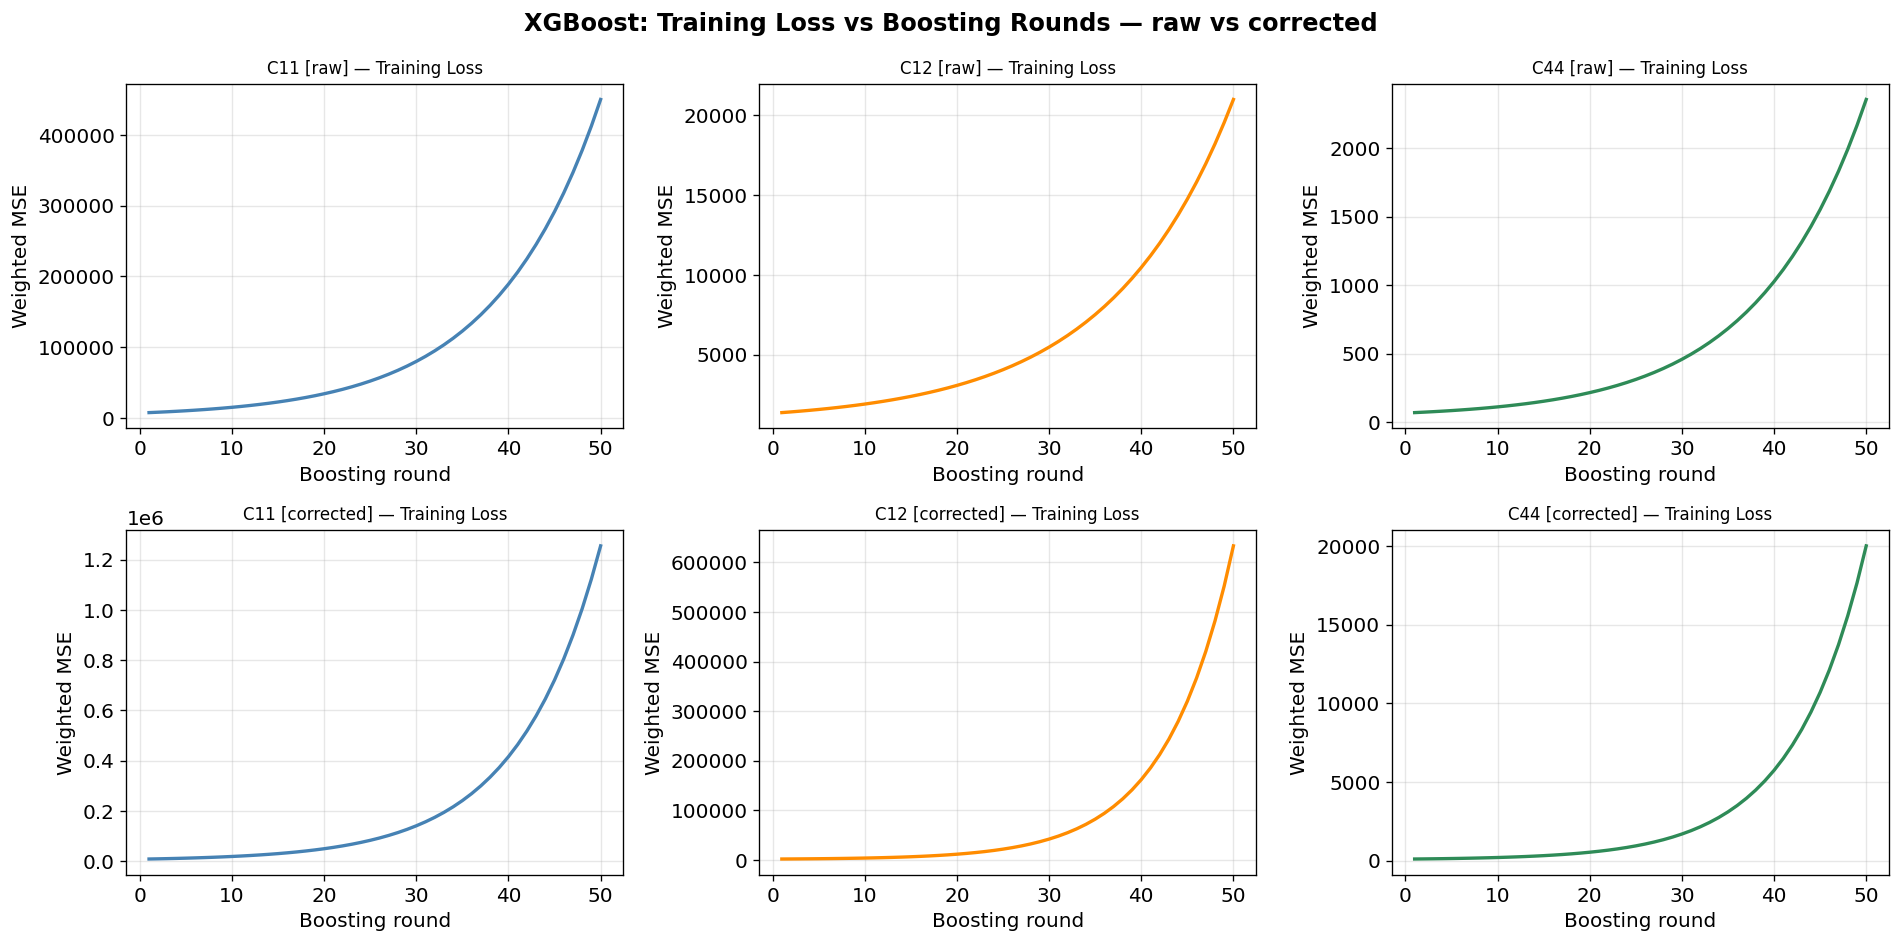

Saved: xgb_training_loss_comparison.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax   = axes[row_idx, col_idx]
        loss = r['xgb_results'][tname]['train_loss']
        ax.plot(range(1, len(loss)+1), loss,
                color=PALETTE[tname], lw=2)
        ax.set_xlabel('Boosting round')
        ax.set_ylabel('Weighted MSE')
        ax.set_title(f'{tname} [{mode}] — Training Loss', fontsize=10)
        ax.grid(alpha=0.3)

plt.suptitle('XGBoost: Training Loss vs Boosting Rounds — raw vs corrected',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/xgb_training_loss_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: xgb_training_loss_comparison.png')

---
## Cell 7 — Prediction Plots

XGBoost has no native uncertainty output.
The shaded region shows ±MAE (LOO) as a practical error band.

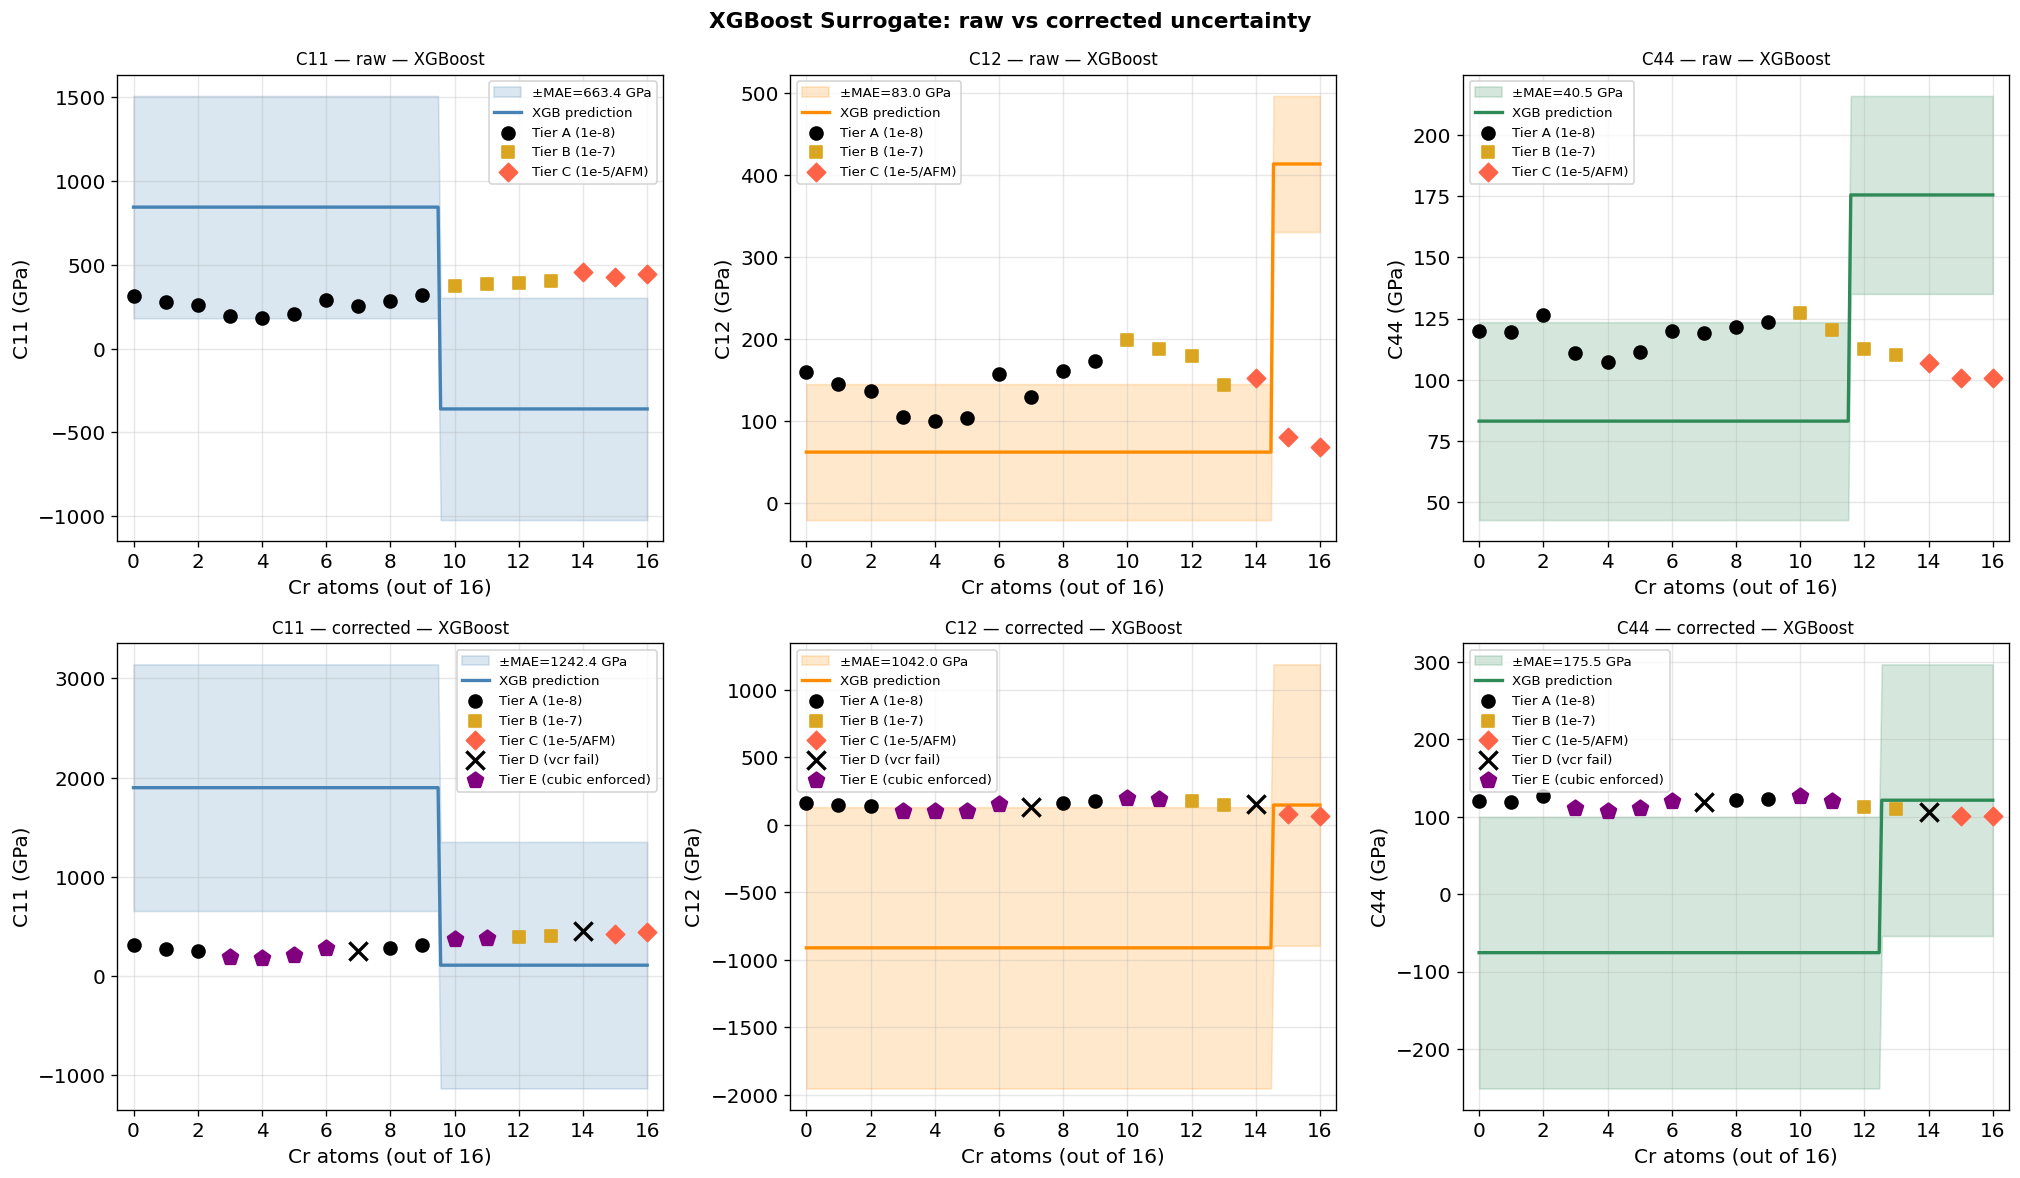

Saved: xgb_predictions_comparison.png


In [9]:
tier_specs = [
    ('A', 'black',     'o', 'Tier A (1e-8)'),
    ('B', 'goldenrod', 's', 'Tier B (1e-7)'),
    ('C', 'tomato',    'D', 'Tier C (1e-5/AFM)'),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        res = r['xgb_results'][tname]
        mu  = res['mu']
        mae = res['mae']
        col = PALETTE[tname]

        ax.fill_between(r['x_pred_atoms'], mu-mae, mu+mae,
                        alpha=0.20, color=col,
                        label=f'±MAE={mae:.1f} GPa')
        ax.plot(r['x_pred_atoms'], mu, '-', color=col,
                lw=2, label='XGB prediction')

        # Tier A/B/C — exclude D and E
        for t_lbl, col_s, mk, lbl in tier_specs:
            m = ((r['tier'] == t_lbl)
                 & ~r['vcr_geometry']
                 & ~r['cubic_enforced'])
            if m.any():
                ax.scatter(r['df']['n_cr'][m],
                           r['targets'][tname][m],
                           color=col_s, s=60, marker=mk,
                           zorder=5, label=lbl)

        # Tier D
        if r['vcr_geometry'].any():
            ax.scatter(r['df']['n_cr'][r['vcr_geometry']],
                       r['targets'][tname][r['vcr_geometry']],
                       color='black', s=120, marker='x',
                       linewidths=2, zorder=6,
                       label='Tier D (vcr fail)')

        # Tier E
        cub = r['cubic_enforced'] & ~r['vcr_geometry']
        if cub.any():
            ax.scatter(r['df']['n_cr'][cub],
                       r['targets'][tname][cub],
                       color='purple', s=90, marker='p',
                       linewidths=1.5, zorder=5,
                       label='Tier E (cubic enforced)')

        ax.set_xlabel('Cr atoms (out of 16)')
        ax.set_ylabel(f'{tname} (GPa)')
        ax.set_title(f'{tname} — {mode} — XGBoost', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xlim(-0.5, 16.5)

plt.suptitle('XGBoost Surrogate: raw vs corrected uncertainty',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../analysis/xgb_predictions_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: xgb_predictions_comparison.png')

---
## Cell 8 — LOO-CV Residuals

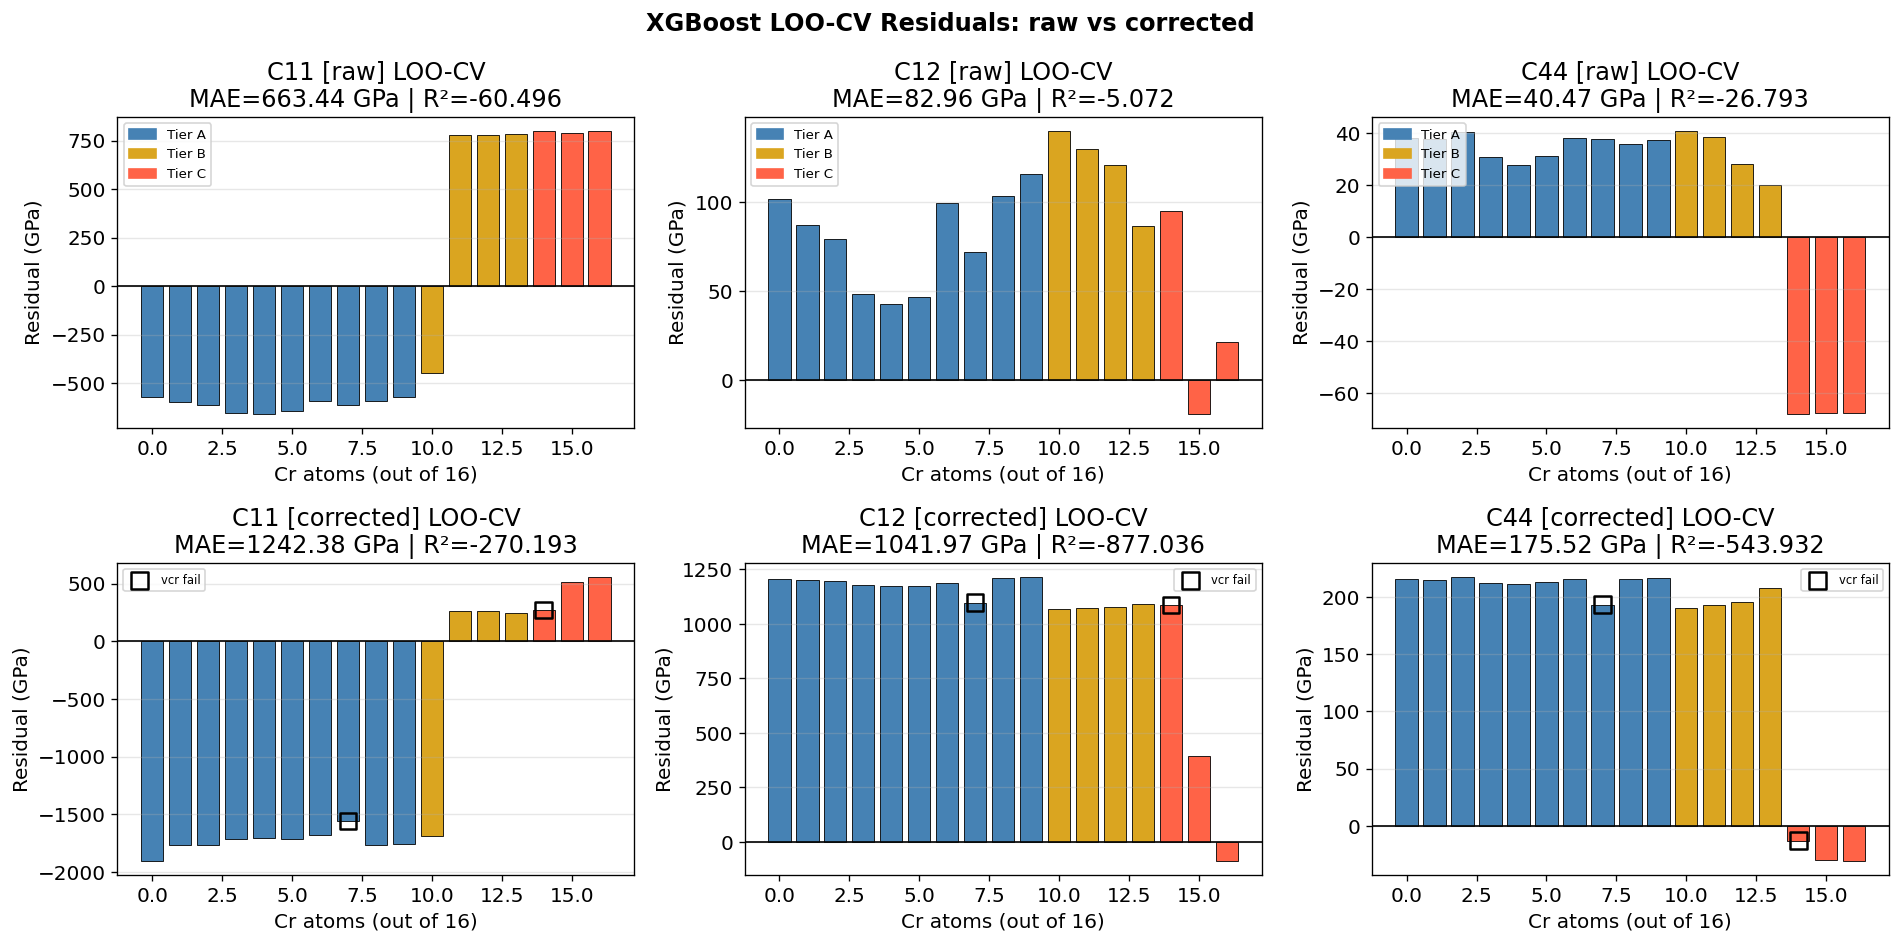

Saved: xgb_loo_residuals_comparison.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for row_idx, mode in enumerate(DATA_PATHS):
    r = results[mode]
    for col_idx, tname in enumerate(TARGETS):
        ax  = axes[row_idx, col_idx]
        res = r['xgb_results'][tname]
        plot_loo_residuals(
            ax,
            res['residuals'],
            r['df']['n_cr'].values,
            r['tier'],
            f"{tname} [{mode}] LOO-CV\n"
            f"MAE={res['mae']:.2f} GPa | R²={res['r2']:.3f}"
        )
        # vcr fail overlay
        if r['vcr_geometry'].any():
            ax.scatter(r['df']['n_cr'][r['vcr_geometry']],
                       res['residuals'][r['vcr_geometry']],
                       marker='s', s=100, facecolors='none',
                       edgecolors='black', linewidths=1.5,
                       zorder=5, label='vcr fail')
            ax.legend(fontsize=7)

plt.suptitle('XGBoost LOO-CV Residuals: raw vs corrected',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../analysis/xgb_loo_residuals_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: xgb_loo_residuals_comparison.png')

---
## Cell 9 — Export Results

In [11]:
for mode in DATA_PATHS:
    r   = results[mode]
    exp = {}
    for tname in TARGETS:
        res = r['xgb_results'][tname]
        exp[tname] = dict(
            mu           = res['mu'],
            mae          = res['mae'],
            r2           = res['r2'],
            loo_true     = res['loo_true'],
            loo_preds    = res['loo_preds'],
            residuals    = res['residuals'],
            best_params  = res['best_params'],
            train_loss   = res['train_loss'],
        )
    pkl_path = f'../analysis/xgb_results_{mode}.pkl'
    with open(pkl_path, 'wb') as f:
        pickle.dump(exp, f)
    print(f'Saved: xgb_results_{mode}.pkl')

print('\nXGBoost Summary:')
for mode in DATA_PATHS:
    print(f'\n  [{mode.upper()}]')
    for tname in TARGETS:
        res = results[mode]['xgb_results'][tname]
        n, eta = res['best_params']
        print(f'    {tname}: n={n:3d}  η={eta:.2f}  '
              f'MAE={res["mae"]:.2f} GPa  R²={res["r2"]:.4f}')

Saved: xgb_results_raw.pkl
Saved: xgb_results_corrected.pkl

XGBoost Summary:

  [RAW]
    C11: n= 50  η=0.05  MAE=663.44 GPa  R²=-60.4955
    C12: n= 50  η=0.05  MAE=82.96 GPa  R²=-5.0718
    C44: n= 50  η=0.05  MAE=40.47 GPa  R²=-26.7931

  [CORRECTED]
    C11: n= 50  η=0.05  MAE=1242.38 GPa  R²=-270.1929
    C12: n= 50  η=0.05  MAE=1041.97 GPa  R²=-877.0364
    C44: n= 50  η=0.05  MAE=175.52 GPa  R²=-543.9320
